Loaded existing FCC lattice:
/exp/e961/data/MDsims-data/pnichols/Simple_Lattices_v2/FCC/n_cells_3/rho_0.400/lattice.gsd
Using GPU device
Final device: <hoomd.device.GPU object at 0x7fe1d30c9260>
n_fcc_cells = 3
target_rho = 0.4
actual_rho = 0.4000000050648069
N = 108
Box L = 6.463304042816162
volume = 269.9999965812554
min position = [-3.23165202 -3.23165202 -3.23165202]
max position = [2.15443468 2.15443468 2.15443468]
outside box count = 0
center of mass = [-0.53860867 -0.53860867 -0.53860867]
mean distance from COM = 3.0688725628241014
max distance from COM = 4.6644879112178845


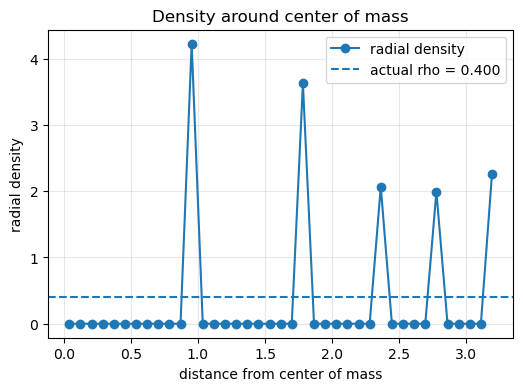

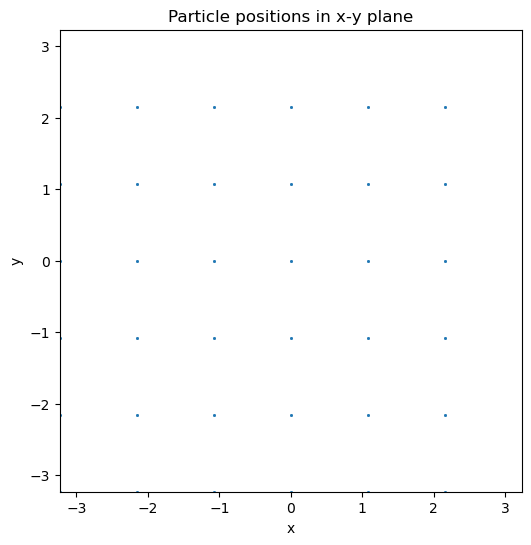

In [10]:
# ============================================================
# Diagnose whether FCC "center clumping" is real or visualization
# V2 version: fixed n_fcc_cells, derived BoxLength
# ============================================================

# ============================================================
# Imports
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import hoomd
import importlib

import md_Helpers.Project_Paths as pp
import md_Helpers.Create_Lattices as cl
import md_Helpers.Simulation_Helpers as sh
import md_Helpers.Logging_Helpers as lh
import md_Helpers.viz_helpers as vh

importlib.reload(pp)
importlib.reload(cl)
importlib.reload(sh)
importlib.reload(lh)
importlib.reload(vh)


# ============================================================
# User settings
# ============================================================

n_fcc_cells = 3
target_rho = 0.40
kT = 0.40


# ============================================================
# Build/load V2 FCC lattice
# ============================================================

frame = cl.make_lattice_frame(
    n_fcc_cells=n_fcc_cells,
    target_rho=target_rho,
    end_print=True,
    overwrite=False,
)


# ============================================================
# Create simulation using V2 metadata
# ============================================================

sim = sh.make_simulation(
    frame=frame,
    n_fcc_cells=n_fcc_cells,
    target_rho=target_rho,
    kT=kT,
)


# ============================================================
# Thermalize momenta but do not evolve positions
# ============================================================

sim = sh.thermalize_and_randomize(
    simulation=sim,
    kT=kT,
    nsteps=0,
    log=False,
)


# ============================================================
# Get current snapshot
# ============================================================

snap = sim.state.get_snapshot()

pos = np.asarray(
    snap.particles.position,
    dtype=float,
).copy()

N = int(snap.particles.N)
L = float(snap.configuration.box[0])
volume = L**3
actual_rho = N / volume


# ============================================================
# Basic checks
# ============================================================
print("n_fcc_cells =", n_fcc_cells)
print("target_rho =", target_rho)
print("actual_rho =", actual_rho)
print("N =", N)
print("Box L =", L)
print("volume =", volume)

print("min position =", pos.min(axis=0))
print("max position =", pos.max(axis=0))

outside_box = np.sum(
    np.any(
        (pos < -L / 2) | (pos >= L / 2),
        axis=1,
    )
)

print("outside box count =", outside_box)


# ============================================================
# Center-of-mass diagnostics
# ============================================================

com = pos.mean(axis=0)
r_from_com = np.linalg.norm(pos - com, axis=1)

print("center of mass =", com)
print("mean distance from COM =", r_from_com.mean())
print("max distance from COM =", r_from_com.max())


# ============================================================
# Radial density around center of mass
# ============================================================

bins = np.linspace(
    0,
    L / 2,
    40,
)

counts, edges = np.histogram(
    r_from_com,
    bins=bins,
)

shell_volumes = (
    4.0 / 3.0
    * np.pi
    * (edges[1:]**3 - edges[:-1]**3)
)

rho_r = counts / shell_volumes
r_centers = 0.5 * (edges[1:] + edges[:-1])

plt.figure(figsize=(6, 4))

plt.plot(
    r_centers,
    rho_r,
    marker="o",
    label="radial density",
)

plt.axhline(
    actual_rho,
    linestyle="--",
    label=f"actual rho = {actual_rho:.3f}",
)

plt.xlabel("distance from center of mass")
plt.ylabel("radial density")
plt.title("Density around center of mass")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ============================================================
# XY plot
# ============================================================

vh.plot_xy_particles(
    sim,
    point_size=1,
    alpha=0.7,
)


kT = 0.4
Created new FCC lattice
----------------------------
n_fcc_cells = 30
N = 108000
Target rho = 0.39
Actual rho = 0.3900000000000004
Density error = 3.885780586188048e-16
BoxLength = 65.18080445080042
FCC cell size = 2.1726934816933476
Saved lattice to:
/exp/e961/data/MDsims-data/pnichols/Simple_Lattices_v2/FCC/n_cells_30/rho_0.390/lattice.gsd
Using GPU device
Final device: <hoomd.device.GPU object at 0x7fe1d307b230>


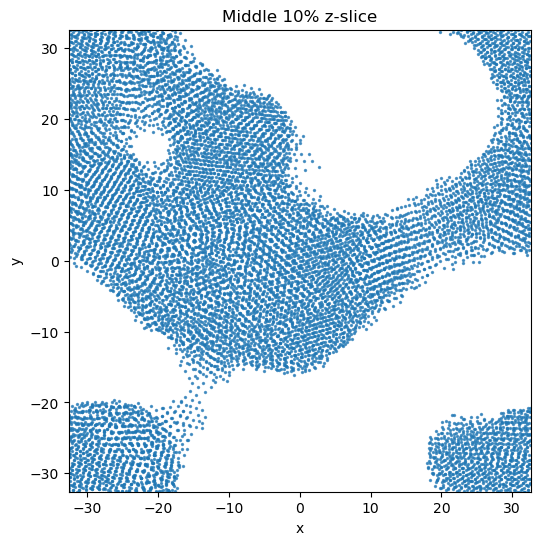

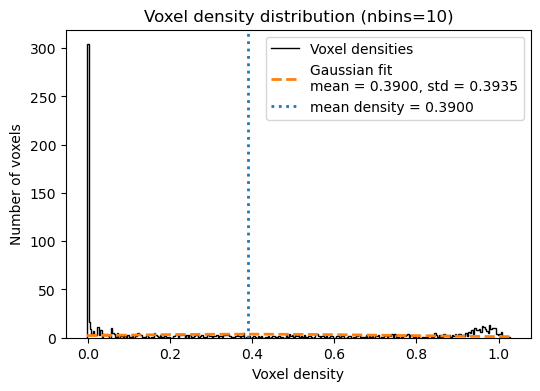

Voxel density summary
nbins:              10
number of voxels:   1000
voxel volume:       276.9230769230767
mean density:       0.39000000000000035
std density:        0.39352801338915333
min density:        0.0
max density:        1.0255555555555564


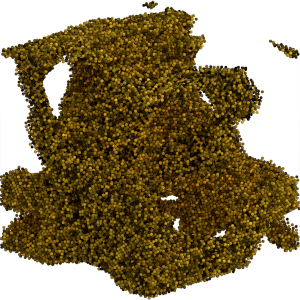


kT = 1.5
Loaded existing FCC lattice:
/exp/e961/data/MDsims-data/pnichols/Simple_Lattices_v2/FCC/n_cells_30/rho_0.390/lattice.gsd
Using GPU device
Final device: <hoomd.device.GPU object at 0x7fe1caeb3bb0>


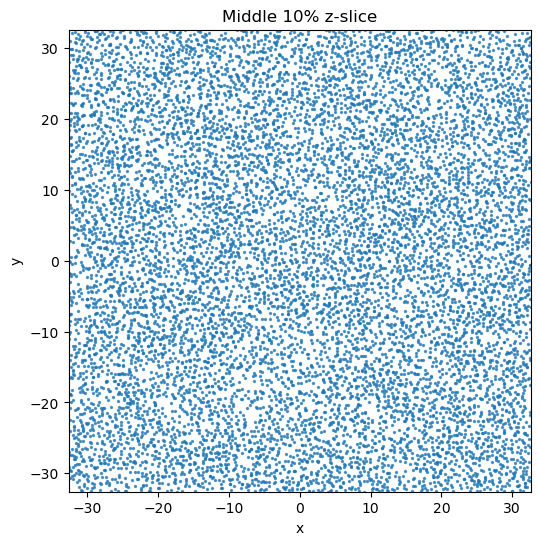

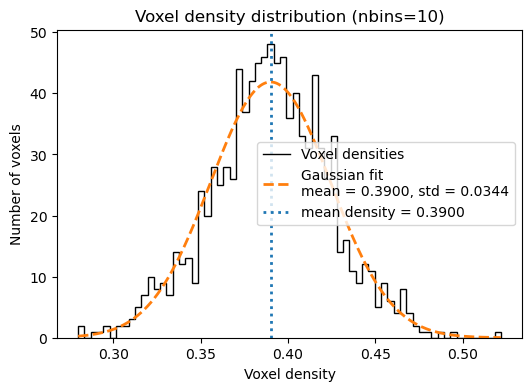

Voxel density summary
nbins:              10
number of voxels:   1000
voxel volume:       276.92303793171743
mean density:       0.390000054912839
std density:        0.03442373911757325
min density:        0.28166670632593926
max density:        0.5200000732171187


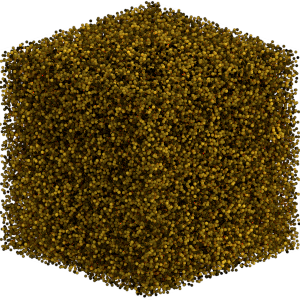


kT = 3.0
Loaded existing FCC lattice:
/exp/e961/data/MDsims-data/pnichols/Simple_Lattices_v2/FCC/n_cells_30/rho_0.390/lattice.gsd
Using GPU device
Final device: <hoomd.device.GPU object at 0x7fe1d2fb7650>


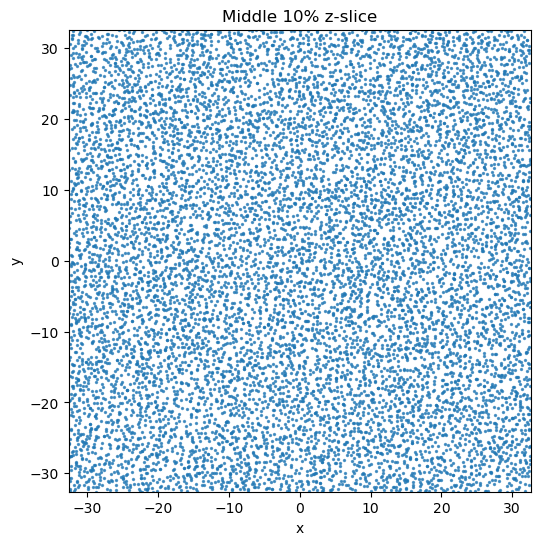

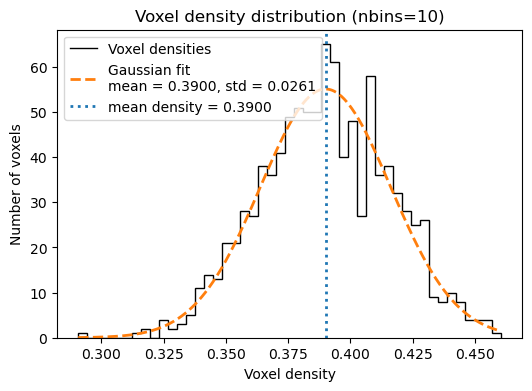

Voxel density summary
nbins:              10
number of voxels:   1000
voxel volume:       276.92303793171743
mean density:       0.390000054912839
std density:        0.02613915970546142
min density:        0.29250004118462924
max density:        0.4586111756845422


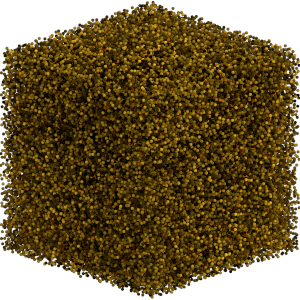

In [9]:
# ============================================================
# Compare low kT vs high kT behavior
# V2 version: fixed n_fcc_cells, derived BoxLength
# ============================================================

n_fcc_cells = 30
target_rho = 0.39

nsteps = 50_000

for kT_test in [0.4, 1.5, 3.0]:
    print("\n" + "=" * 80)
    print("kT =", kT_test)
    print("=" * 80)

    # ============================================================
    # Build/load V2 FCC lattice
    # ============================================================

    frame = cl.make_lattice_frame(
        n_fcc_cells=n_fcc_cells,
        target_rho=target_rho,
        end_print=True,
        overwrite=False,
    )

    # ============================================================
    # Create V2 simulation
    # ============================================================

    sim_test = sh.make_simulation(
        frame=frame,
        n_fcc_cells=n_fcc_cells,
        target_rho=target_rho,
        kT=kT_test,
    )

    # ============================================================
    # Thermalize momenta and run
    # ============================================================

    sim_test.state.thermalize_particle_momenta(
        filter=hoomd.filter.All(),
        kT=kT_test,
    )

    sim_test.run(0)
    sim_test.run(nsteps)

    # ============================================================
    # Visual diagnostics
    # ============================================================

    vh.plot_xy_slice(
        sim_test,
        fraction=0.10,
        point_size=2,
        alpha=0.7,
    )

    vh.plot_voxel_histogram(
        sim_test,
        nbins=10,
    )

    display(vh.render(sim_test))